Matplotlib is building the font cache; this may take a moment.


🚀 Exploration des données Multi-Timeframe

✅ EURUSD D1 → 2,656 lignes | 2016-01-04 → 2026-03-25
✅ EURUSD H1 → 63,557 lignes | 2016-01-04 → 2026-03-25
✅ EURUSD H4 → 15,913 lignes | 2016-01-04 → 2026-03-25
✅ EURUSD M1 → 3,805,376 lignes | 2016-01-04 → 2026-03-25
✅ EURUSD M3 → 1,269,698 lignes | 2016-01-04 → 2026-03-25
✅ EURUSD MN1 → 123 lignes | 2016-01-01 → 2026-03-01
✅ EURUSD W1 → 534 lignes | 2016-01-03 → 2026-03-22
✅ GBPUSD D1 → 2,656 lignes | 2016-01-04 → 2026-03-25
✅ GBPUSD H1 → 63,562 lignes | 2016-01-04 → 2026-03-25
✅ GBPUSD H4 → 15,913 lignes | 2016-01-04 → 2026-03-25
✅ GBPUSD M1 → 3,805,091 lignes | 2016-01-04 → 2026-03-25
✅ GBPUSD M3 → 1,269,792 lignes | 2016-01-04 → 2026-03-25
✅ GBPUSD MN1 → 123 lignes | 2016-01-01 → 2026-03-01
✅ GBPUSD W1 → 534 lignes | 2016-01-03 → 2026-03-22
✅ USDCHF D1 → 2,656 lignes | 2016-01-04 → 2026-03-25
✅ USDCHF H1 → 63,560 lignes | 2016-01-04 → 2026-03-25
✅ USDCHF H4 → 15,913 lignes | 2016-01-04 → 2026-03-25
✅ USDCHF M1 → 3,800,993 lignes | 2016-01

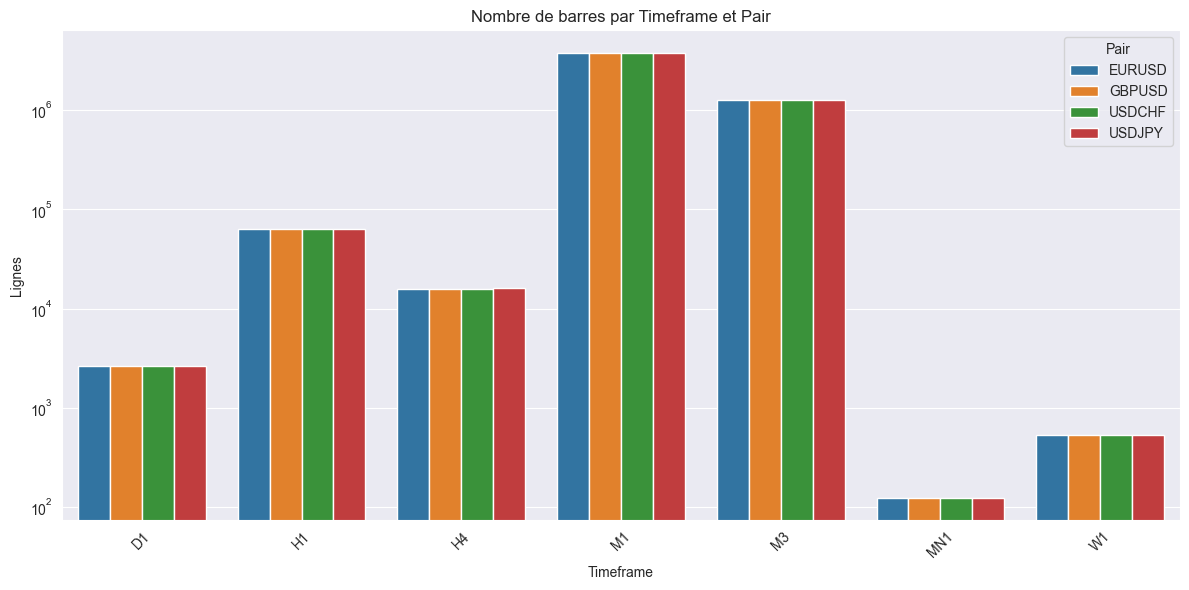

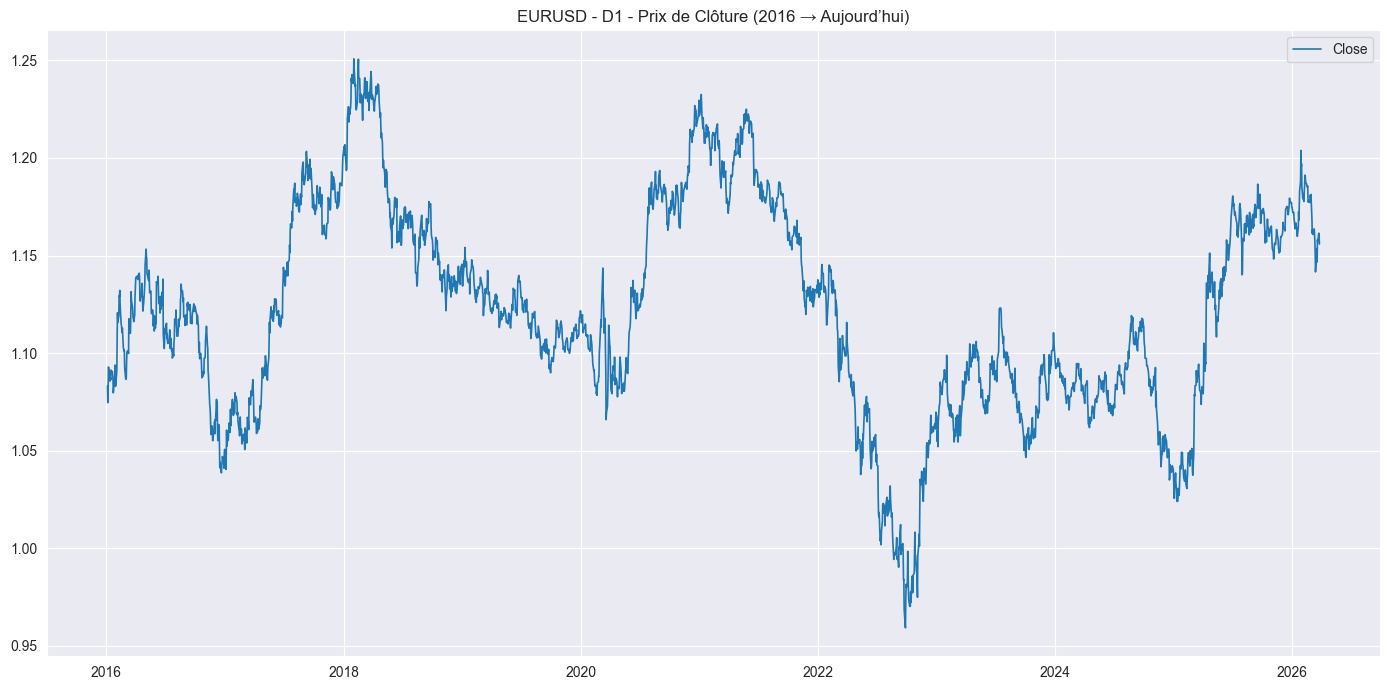

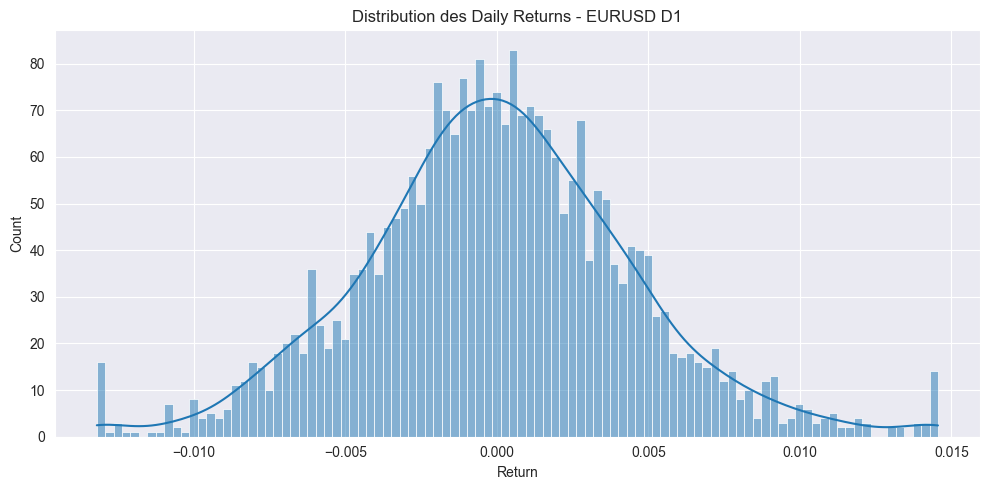


Exploration terminée ! Les graphiques sont affichés.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

CLEAN_DIR = Path("clean_multi_tf")

print("🚀 Exploration des données Multi-Timeframe\n")

files = sorted(glob.glob(str(CLEAN_DIR / "*_clean.csv")))

summary = []

for file in files:
    df = pd.read_csv(file, parse_dates=['timestamp'])
    pair = df['pair'].iloc[0]
    tf = df['timeframe'].iloc[0]
    
    summary.append({
        'Pair': pair,
        'Timeframe': tf,
        'Lignes': len(df),
        'Début': df['timestamp'].min().date(),
        'Fin': df['timestamp'].max().date(),
        'Missing': df.isnull().sum().sum(),
        'Dupliqués': df.duplicated(subset=['timestamp']).sum()
    })
    
    print(f"✅ {pair} {tf} → {len(df):,} lignes | {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

# Tableau résumé
summary_df = pd.DataFrame(summary)
print("\n" + "="*80)
print("RÉSUMÉ GLOBAL")
print("="*80)
print(summary_df.to_string(index=False))

# ===================== VISUALISATIONS =====================
sns.set_style("darkgrid")

# 1. Nombre de lignes par paire et timeframe
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Timeframe', y='Lignes', hue='Pair')
plt.title('Nombre de barres par Timeframe et Pair')
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Exemple : EURUSD - D1 (prix + volume)
eurusd_d1 = pd.read_csv(CLEAN_DIR / "EURUSD_D1_clean.csv", parse_dates=['timestamp'])
plt.figure(figsize=(14, 7))
plt.plot(eurusd_d1['timestamp'], eurusd_d1['close'], label='Close', linewidth=1.2)
plt.title('EURUSD - D1 - Prix de Clôture (2016 → Aujourd’hui)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Distribution des returns (D1)
plt.figure(figsize=(10, 5))
sns.histplot(eurusd_d1['return'].dropna(), bins=100, kde=True)
plt.title('Distribution des Daily Returns - EURUSD D1')
plt.xlabel('Return')
plt.tight_layout()
plt.show()

print("\nExploration terminée ! Les graphiques sont affichés.")

In [ ]:
pip instal